In [46]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2





In [47]:
# 1. LOAD DATA
crabdata = pd.read_csv('CrabAgePrediction.csv') 

In [48]:
crabdata.head()

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6


In [49]:
crabdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3893 entries, 0 to 3892
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3893 non-null   object 
 1   Length          3893 non-null   float64
 2   Diameter        3893 non-null   float64
 3   Height          3893 non-null   float64
 4   Weight          3893 non-null   float64
 5   Shucked Weight  3893 non-null   float64
 6   Viscera Weight  3893 non-null   float64
 7   Shell Weight    3893 non-null   float64
 8   Age             3893 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 273.9+ KB


In [50]:
#remove height=0
crabdata = crabdata[crabdata['Height'] > 0]

In [51]:
print(crabdata.shape)

(3891, 9)


In [52]:
print(crabdata.duplicated().sum())

0


In [53]:
#data on different scales. so we standardize
from sklearn.preprocessing import StandardScaler
#split data to features and label by making a copy of each
X=crabdata[["Sex","Length","Height","Weight","Diameter","Shucked Weight", "Viscera Weight", "Shell Weight","Age"]].copy()
X['Shucked_Weight_Ratio'] = X['Shucked Weight'] / X['Weight']
X['Shell_Weight_Ratio'] = X['Shell Weight'] / X['Weight']
X['Viscera_Weight_Ratio'] = X['Viscera Weight'] / X['Weight']

X.drop(columns=['Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight'], inplace=True)


In [54]:
X.head()

,Sex,Length,Height,Diameter,Age,Shucked_Weight_Ratio,Shell_Weight_Ratio,Viscera_Weight_Ratio
0,F,1.4375,0.4125,1.1750,9,0.500575,0.273878,0.226697
1,M,0.8875,0.2125,0.6500,6,0.425197,0.288714,0.254593
2,I,1.0375,0.2500,0.7750,6,0.406417,0.347594,0.201426
3,F,1.1750,0.2500,0.8875,10,0.352261,0.389064,0.169295
4,I,0.8875,0.2125,0.6625,6,0.501027,0.246407,0.215606


In [55]:
# Create a new DataFrame without Age
X1 = X.drop(columns=['Age'])
X1.head()

,Sex,Length,Height,Diameter,Shucked_Weight_Ratio,Shell_Weight_Ratio,Viscera_Weight_Ratio
0,F,1.4375,0.4125,1.1750,0.500575,0.273878,0.226697
1,M,0.8875,0.2125,0.6500,0.425197,0.288714,0.254593
2,I,1.0375,0.2500,0.7750,0.406417,0.347594,0.201426
3,F,1.1750,0.2500,0.8875,0.352261,0.389064,0.169295
4,I,0.8875,0.2125,0.6625,0.501027,0.246407,0.215606


In [56]:
# Copy target into the y dataframe.This is the dependent variable
y1 = X[['Age']]
y1.head()

,Age
0,9
1,6
2,6
3,10
4,6


In [57]:
#Let us break the X and y dataframes into training set and test set. For this we will use
#Sklearn package's data splitting function which is based on random function

from sklearn.model_selection import train_test_split

# Split X and y into training and test set in 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.20 , random_state=1)

In [58]:
print("--- Data Split Complete For X ---")
print(f"Training set shape: {X_train.shape} (80%)")
print(f"Testing set shape:  {X_test.shape} (20%)")

print("--- Data Split Complete For y ---")
print(f"Training set shape: {y_train.shape} (80%)")
print(f"Testing set shape:  {y_test.shape} (20%)")



--- Data Split Complete For X ---
Training set shape: (3112, 7) (80%)
Testing set shape:  (779, 7) (20%)
--- Data Split Complete For y ---
Training set shape: (3112, 1) (80%)
Testing set shape:  (779, 1) (20%)


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

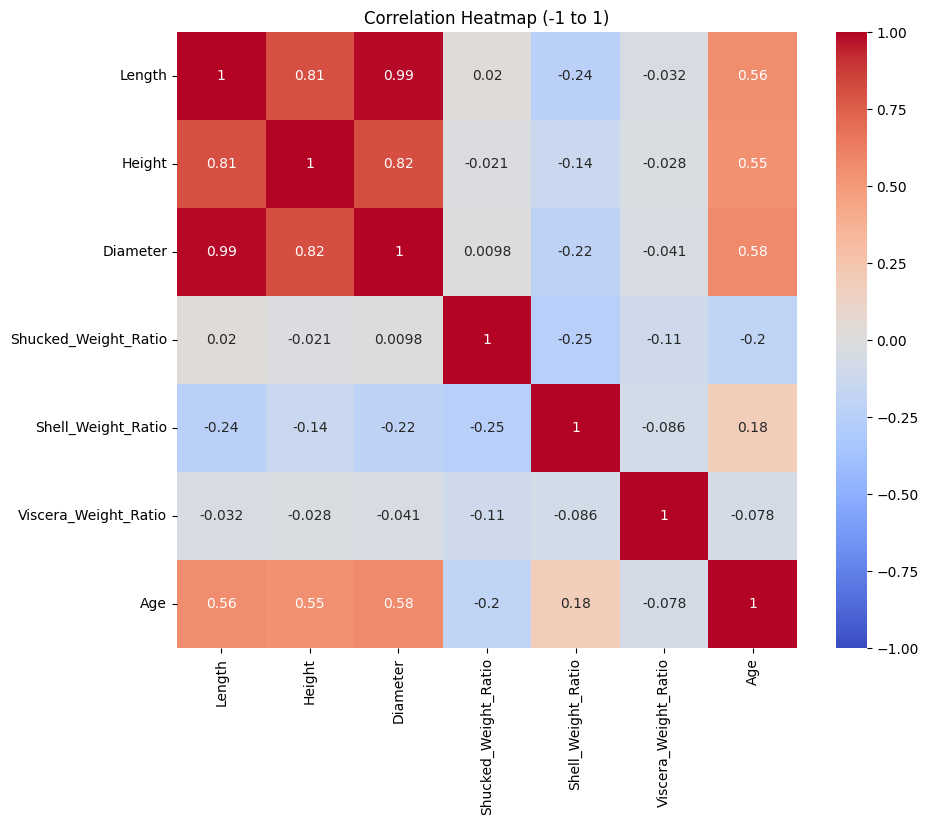

In [60]:
# Combine X_train and y_train for correlation analysis
train_df = pd.concat([X_train, y_train], axis=1)

plt.figure(figsize=(10,8))
sns.heatmap(train_df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1)

plt.title("Correlation Heatmap (-1 to 1)")
plt.show()

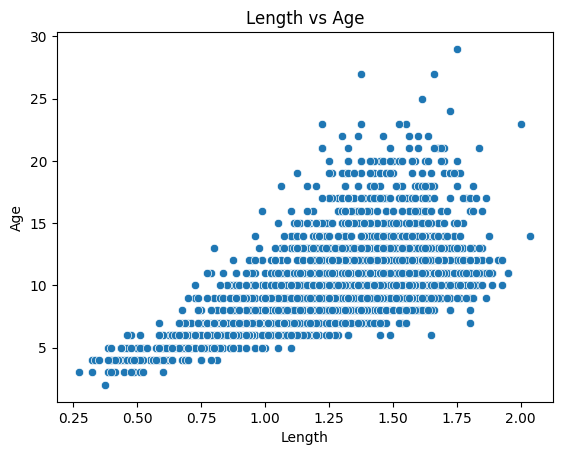

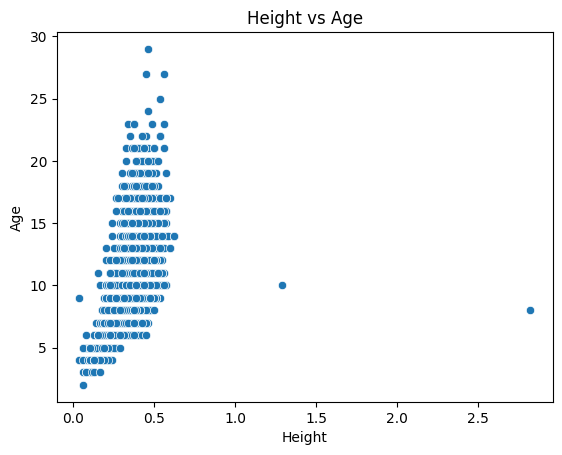

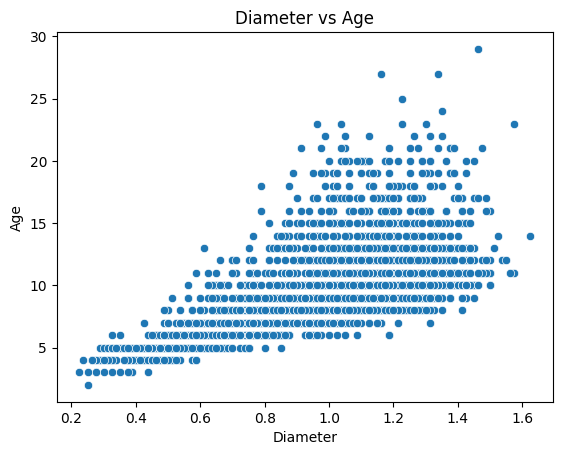

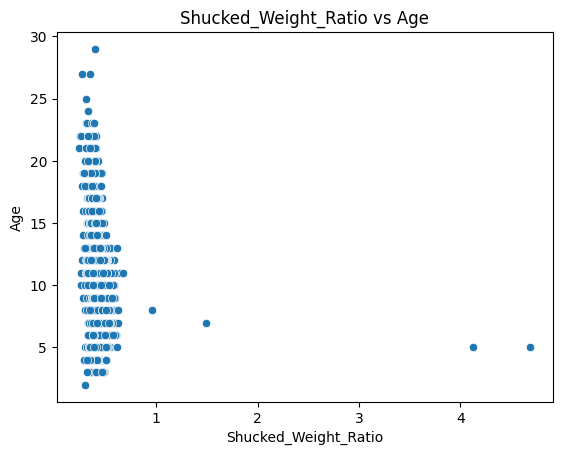

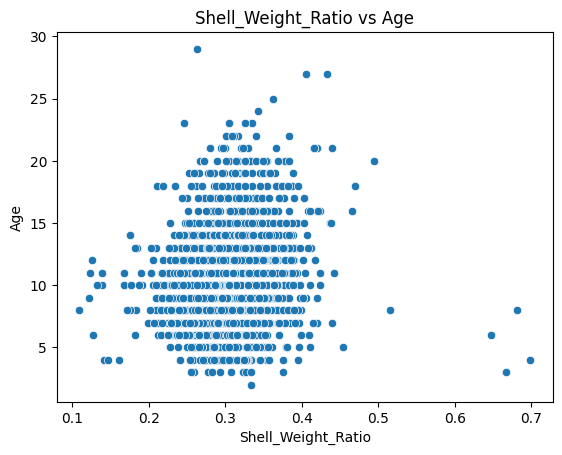

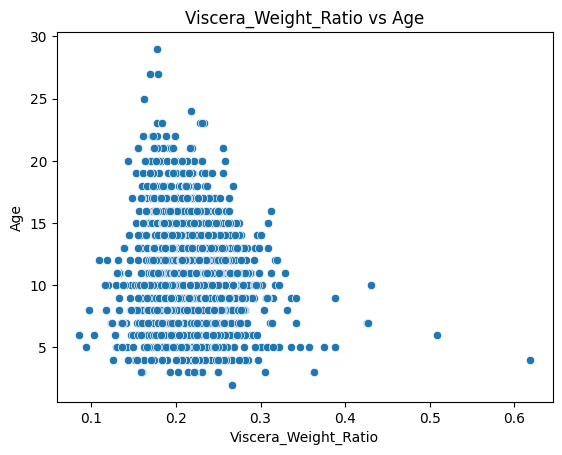

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert y_train to Series if needed
y_train = y_train.squeeze()

# Select numeric columns
X_numeric = X_train.select_dtypes(include=[np.number])

# Combine into one dataframe
plot_df = pd.concat([X_numeric, y_train], axis=1)

# Loop
for col in X_numeric.columns:
    plt.figure()
    sns.scatterplot(data=plot_df, x=col, y=plot_df.columns[-1])
    plt.xlabel(col)
    plt.ylabel("Age")
    plt.title(f"{col} vs Age")
    plt.show()

In [62]:
# Select only numeric columns
X_numeric = X_train.select_dtypes(include=[np.number])

# Add constant
X_vif = sm.add_constant(X_numeric)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(X_vif.shape[1])]

print(vif_data)

                Feature         VIF
0                 const  190.733964
1                Length   39.233831
2                Height    3.023247
3              Diameter   39.903624
4  Shucked_Weight_Ratio    1.093597
5    Shell_Weight_Ratio    1.178115
6  Viscera_Weight_Ratio    1.032152
